# Feature Engineering & Data Transformation

All data processing is delegated to `src.data_processing`. This notebook only visualises the results.

In [1]:
import sys
from pathlib import Path

proj_root = Path.cwd().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from src.data_processing import (
    process_fraud_data, process_creditcard_data,
    prepare_modeling_data_fraud, prepare_modeling_data_credit,
    get_fraud_rate_by_column, get_class_distribution, categorize_hour,
)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

---
## Part 1: Fraud_Data.csv

### 1.1 Full Processing Pipeline

In [2]:
fraud_df, fraud_by_country, significant_countries = process_fraud_data()

PROCESSING: Fraud_Data.csv

Raw shape: (151112, 11)
Missing values:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Duplicate rows: 0
After cleaning: (151112, 11)
Countries mapped. Unique: 182
Saved fraud_data_features.csv  shape=(151112, 42)


### 1.2 Geolocation Results

Unique countries: 182

Top 10 countries by transaction count:
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


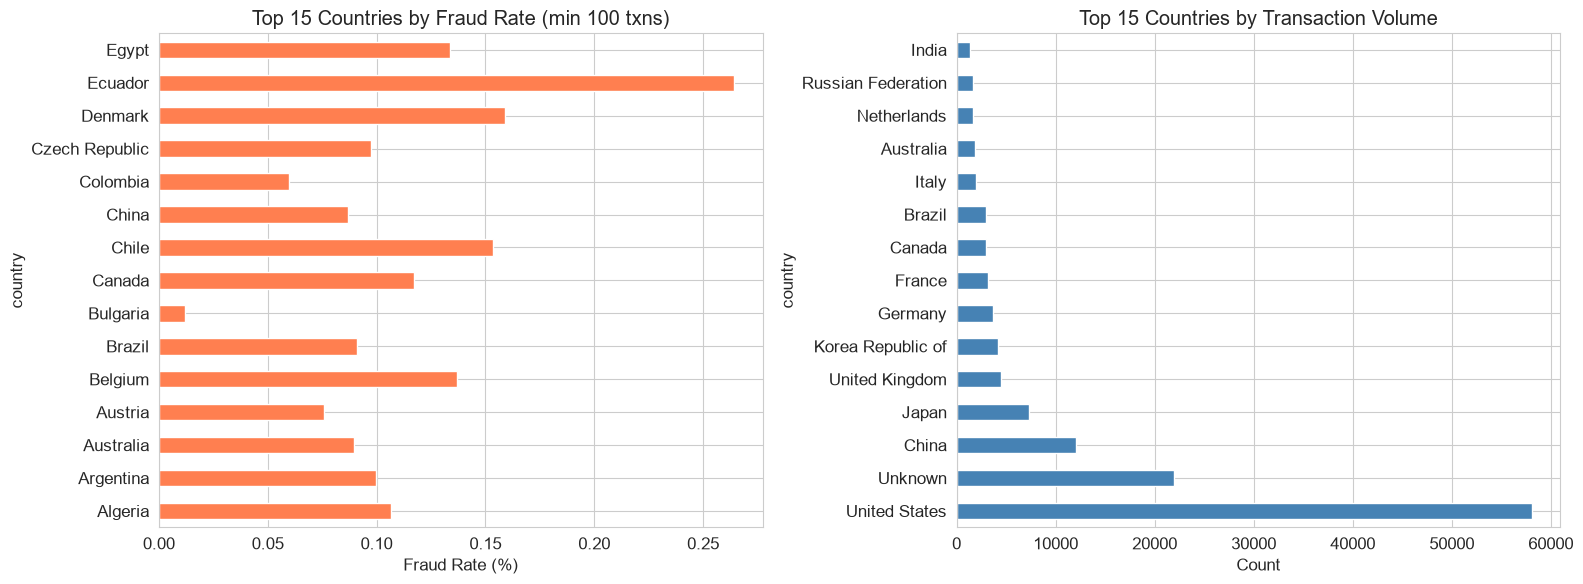

In [3]:
print(f"Unique countries: {fraud_df['country'].nunique()}")
print(f"\nTop 10 countries by transaction count:")
print(fraud_df["country"].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

significant_countries.head(15)["fraud_rate"].plot.barh(ax=axes[0], color="coral")
axes[0].set_title("Top 15 Countries by Fraud Rate (min 100 txns)")
axes[0].set_xlabel("Fraud Rate (%)")

fraud_by_country.sort_values("total_transactions", ascending=False).head(15)["total_transactions"].plot.barh(
    ax=axes[1], color="steelblue")
axes[1].set_title("Top 15 Countries by Transaction Volume")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

In [4]:
high_risk_count = fraud_df["is_high_risk_country"].sum()
print(f"High-risk country transactions: {high_risk_count} ({high_risk_count/len(fraud_df)*100:.2f}%)")
print(f"Fraud rate (high-risk): {fraud_df[fraud_df['is_high_risk_country']==1]['class'].mean()*100:.2f}%")
print(f"Fraud rate (other):     {fraud_df[fraud_df['is_high_risk_country']==0]['class'].mean()*100:.2f}%")

High-risk country transactions: 2377 (1.57%)
Fraud rate (high-risk): 18.85%
Fraud rate (other):     9.21%


### 1.3 Temporal Features

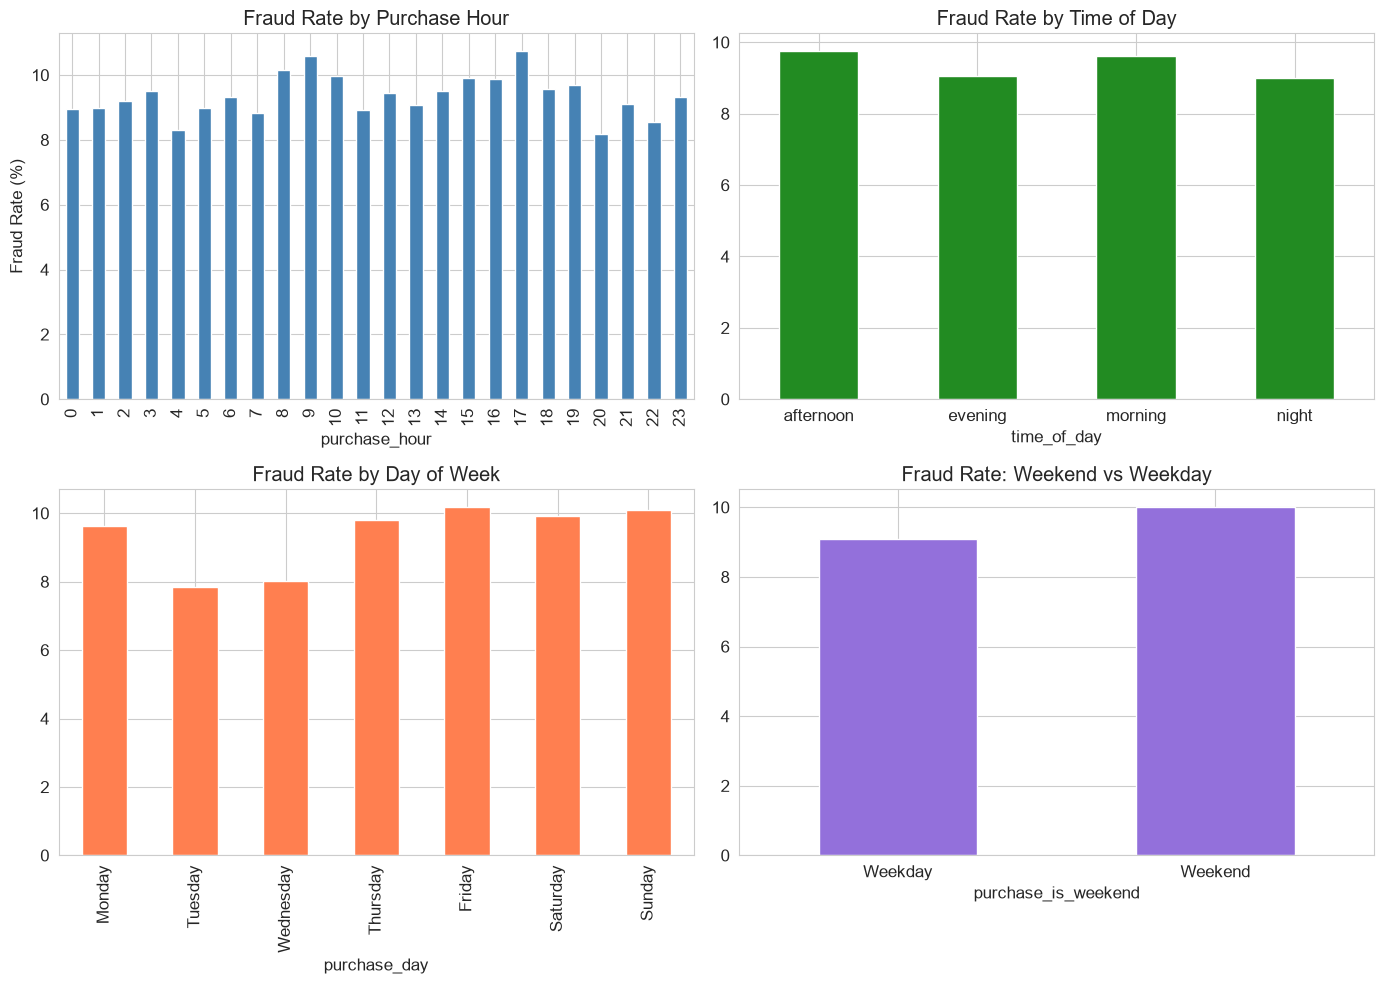

In [5]:
fraud_df["time_of_day"] = fraud_df["purchase_hour"].apply(categorize_hour)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

(fraud_df.groupby("purchase_hour")["class"].mean() * 100).plot.bar(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Fraud Rate by Purchase Hour")
axes[0, 0].set_ylabel("Fraud Rate (%)")

(fraud_df.groupby("time_of_day")["class"].mean() * 100).plot.bar(ax=axes[0, 1], color="forestgreen")
axes[0, 1].set_title("Fraud Rate by Time of Day")
axes[0, 1].tick_params(axis="x", rotation=0)

day_stats = (fraud_df.groupby("purchase_day")["class"].mean() * 100).reindex(day_order)
day_stats.plot.bar(ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Fraud Rate by Day of Week")

(fraud_df.groupby("purchase_is_weekend")["class"].mean() * 100).plot.bar(
    ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Fraud Rate: Weekend vs Weekday")
axes[1, 1].set_xticklabels(["Weekday", "Weekend"], rotation=0)

plt.tight_layout()
plt.show()

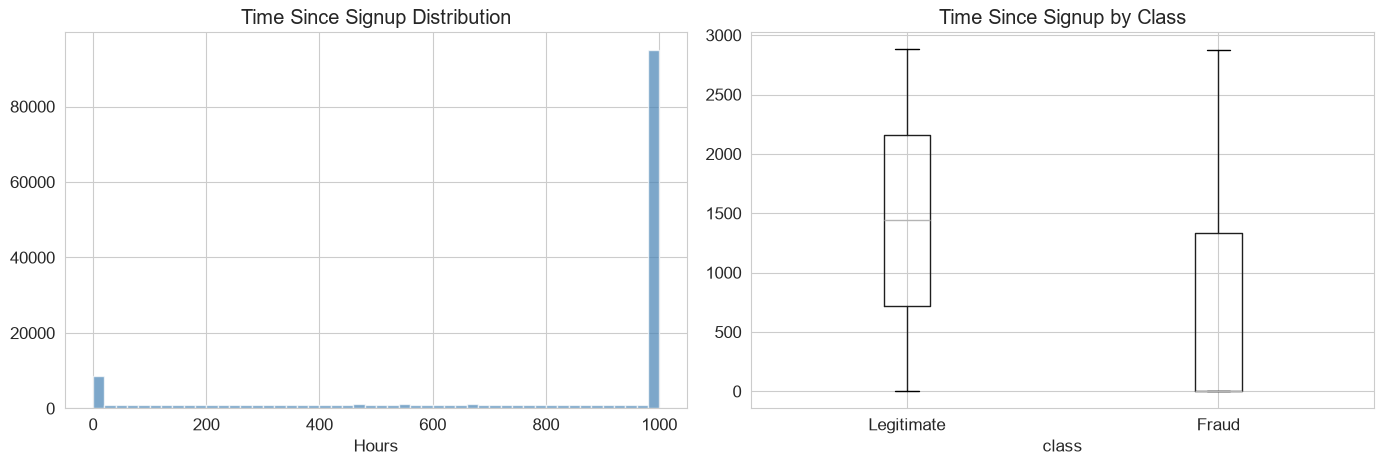

          count         mean         std       min         25%          50%  \
class                                                                         
0      136961.0  1441.994052  830.163558  0.038056  719.119167  1443.030833   
1       14151.0   673.289542  920.496897  0.000278    0.000278     0.000278   

               75%          max  
class                            
0      2161.477500  2879.992222  
1      1330.697361  2878.874167  


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_df["time_since_signup"].clip(upper=1000).hist(bins=50, ax=axes[0], color="steelblue", alpha=0.7)
axes[0].set_title("Time Since Signup Distribution")
axes[0].set_xlabel("Hours")

fraud_df.boxplot(column="time_since_signup", by="class", ax=axes[1])
axes[1].set_title("Time Since Signup by Class")
axes[1].set_xticklabels(["Legitimate", "Fraud"])
plt.suptitle("")

plt.tight_layout()
plt.show()

print(fraud_df.groupby("class")["time_since_signup"].describe())

### 1.4 Velocity Features

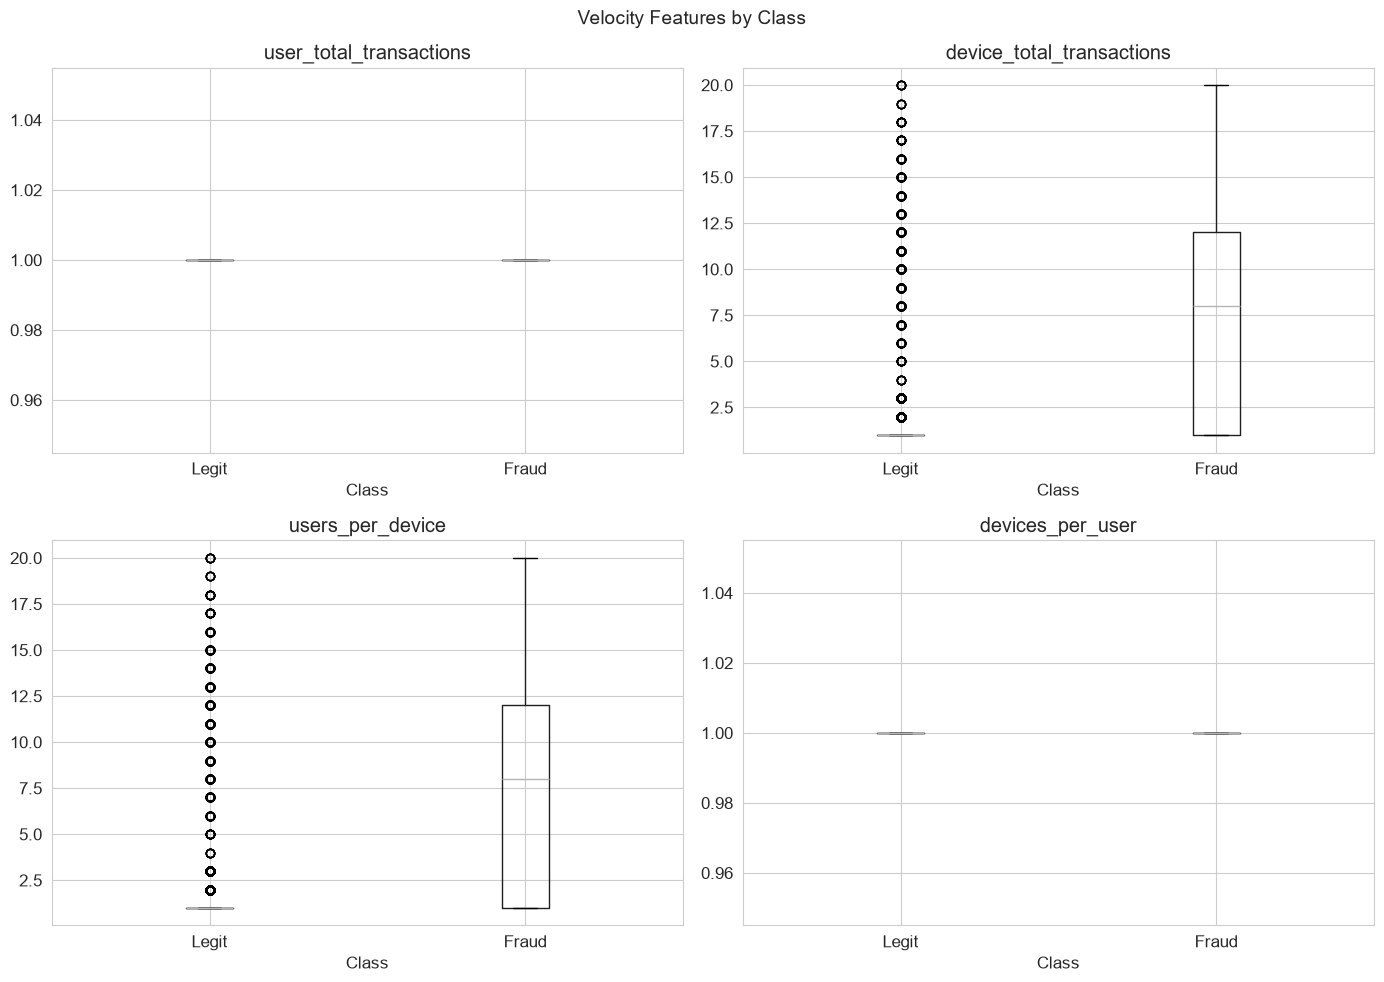

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, [
    "user_total_transactions", "device_total_transactions",
    "users_per_device", "devices_per_user",
]):
    fraud_df.boxplot(column=col, by="class", ax=ax)
    ax.set_title(col)
    ax.set_xticklabels(["Legit", "Fraud"])
    ax.set_xlabel("Class")

plt.suptitle("Velocity Features by Class", fontsize=14)
plt.tight_layout()
plt.show()

### 1.5 Prepare Modeling Data

In [8]:
X_train, X_test, y_train, y_test, X_train_smote, y_train_smote, feature_cols = \
    prepare_modeling_data_fraud(fraud_df)

print(f"\nFeatures: {len(feature_cols)}")
print(f"\nBefore SMOTE:")
get_class_distribution(y_train, "(Train)")
print(f"\nAfter SMOTE:")
get_class_distribution(y_train_smote, "(Train SMOTE)")


Train: (120889, 30), Test: (30223, 30)
After SMOTE: (164352, 30)

Features: 30

Before SMOTE:

Class Distribution (Train):
  Class 0: 109,568 (90.64%)
  Class 1: 11,321 (9.36%)
  Imbalance Ratio: 9.7:1

After SMOTE:

Class Distribution (Train SMOTE):
  Class 0: 109,568 (66.67%)
  Class 1: 54,784 (33.33%)
  Imbalance Ratio: 2.0:1


{np.int64(0): {'count': np.int64(109568),
  'percentage': np.float64(66.66666666666666)},
 np.int64(1): {'count': np.int64(54784),
  'percentage': np.float64(33.33333333333333)}}

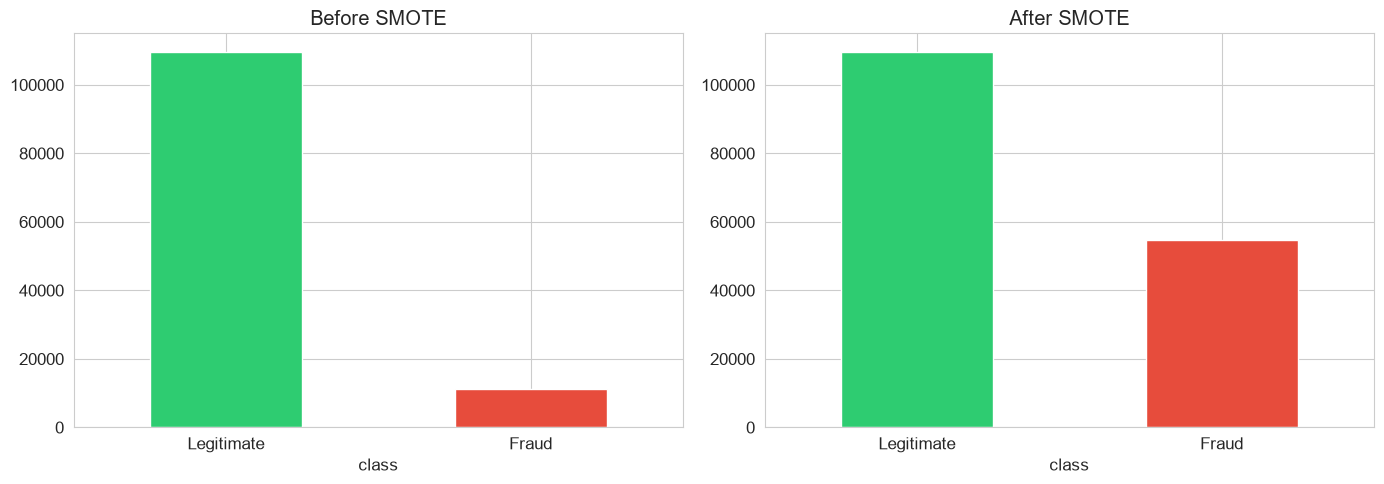

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train.value_counts().plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Before SMOTE")
axes[0].set_xticklabels(["Legitimate", "Fraud"], rotation=0)

pd.Series(y_train_smote).value_counts().plot.bar(ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("After SMOTE")
axes[1].set_xticklabels(["Legitimate", "Fraud"], rotation=0)

plt.tight_layout()
plt.show()

---
## Part 2: creditcard.csv

### 2.1 Full Processing Pipeline

In [10]:
credit_df = process_creditcard_data()

PROCESSING: creditcard.csv

Raw shape: (284807, 31)
Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Duplicate rows: 1081
After cleaning: (283726, 31)
Saved creditcard_features.csv  shape=(283726, 33)


### 2.2 New Feature Visualisations

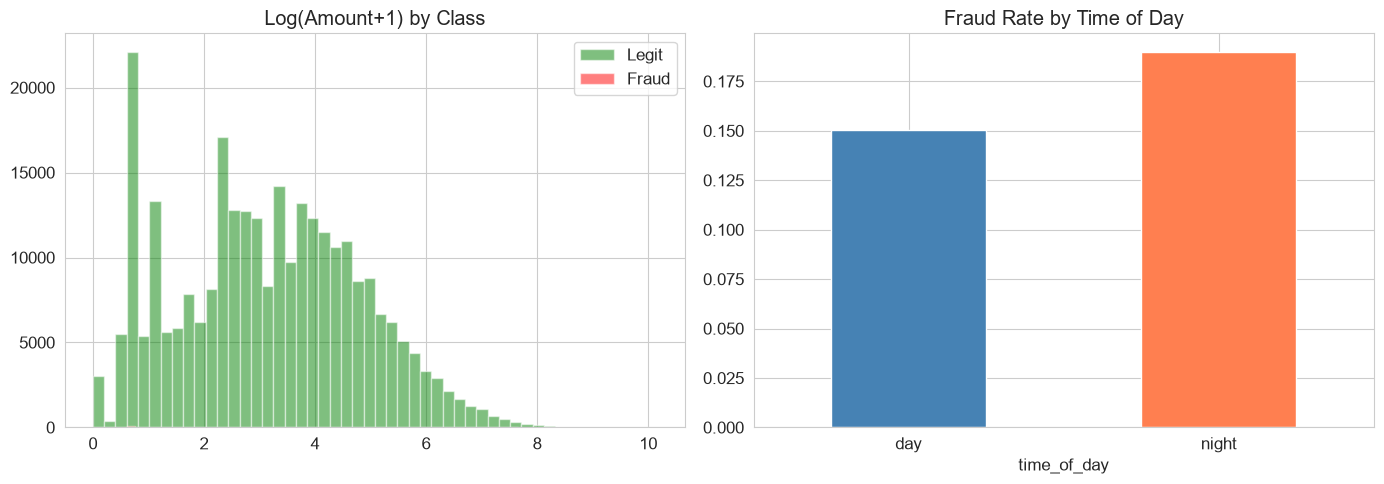

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

credit_df[credit_df["Class"] == 0]["Amount_log"].hist(
    bins=50, alpha=0.5, label="Legit", color="green", ax=axes[0])
credit_df[credit_df["Class"] == 1]["Amount_log"].hist(
    bins=50, alpha=0.5, label="Fraud", color="red", ax=axes[0])
axes[0].set_title("Log(Amount+1) by Class")
axes[0].legend()

credit_df["Time_hours"] = credit_df["Time"] / 3600
credit_df["time_of_day"] = credit_df["Time_hours"].apply(
    lambda x: "night" if (x % 24) < 6 or (x % 24) >= 18 else "day")
(credit_df.groupby("time_of_day")["Class"].mean() * 100).plot.bar(
    ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Fraud Rate by Time of Day")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 2.3 Prepare Modeling Data

In [12]:
X_train_c, X_test_c, y_train_c, y_test_c, X_train_smote_c, y_train_smote_c, feature_cols_c = \
    prepare_modeling_data_credit(credit_df)

print(f"\nFeatures: {len(feature_cols_c)}")
print(f"\nBefore SMOTE:")
get_class_distribution(y_train_c, "(Train)")
print(f"\nAfter SMOTE:")
get_class_distribution(y_train_smote_c, "(Train SMOTE)")


Train: (226980, 30), Test: (56746, 30)
After SMOTE: (294582, 30)

Features: 30

Before SMOTE:

Class Distribution (Train):
  Class 0: 226,602 (99.83%)
  Class 1: 378 (0.17%)
  Imbalance Ratio: 599.5:1

After SMOTE:

Class Distribution (Train SMOTE):
  Class 0: 226,602 (76.92%)
  Class 1: 67,980 (23.08%)
  Imbalance Ratio: 3.3:1


{np.int64(0): {'count': np.int64(226602),
  'percentage': np.float64(76.92323359879423)},
 np.int64(1): {'count': np.int64(67980),
  'percentage': np.float64(23.076766401205777)}}

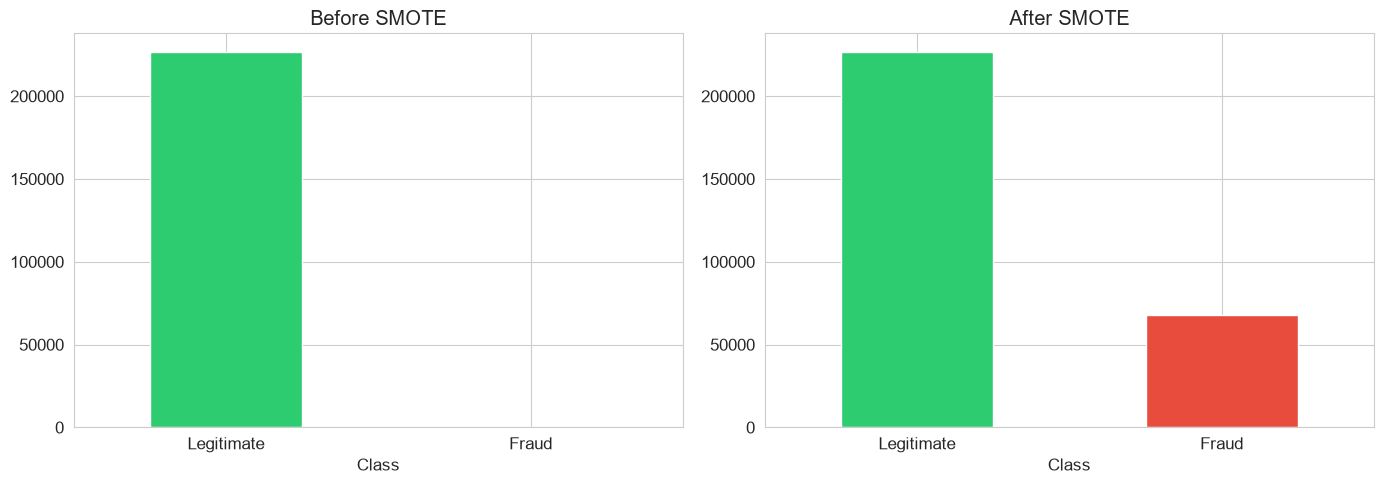

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train_c.value_counts().plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Before SMOTE")
axes[0].set_xticklabels(["Legitimate", "Fraud"], rotation=0)

pd.Series(y_train_smote_c).value_counts().plot.bar(ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("After SMOTE")
axes[1].set_xticklabels(["Legitimate", "Fraud"], rotation=0)

plt.tight_layout()
plt.show()

## Summary

**Fraud_Data.csv**:
- Geolocation integrated (IP-to-country with binary search)
- Temporal features: hour, day, month, weekend, time_since_signup, time_of_day
- Velocity features: user/device transaction counts, fraud rates, unique counts
- Categorical encoding: one-hot for source, browser, sex, time_of_day
- SMOTE 1:2 ratio applied to training set only

**creditcard.csv**:
- Log-transformed Amount, Time converted to hours
- SMOTE 1:3 ratio applied to training set only (more aggressive due to 0.17% fraud)

All processed data saved to `data/processed/`.